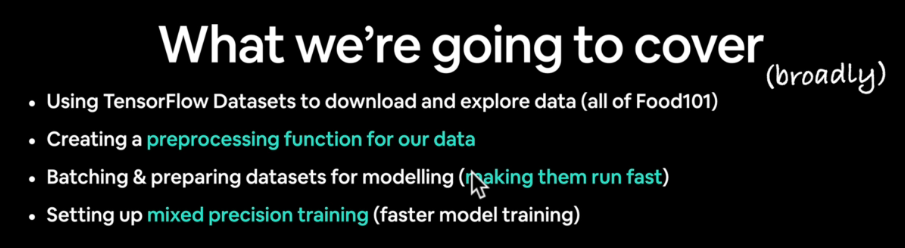

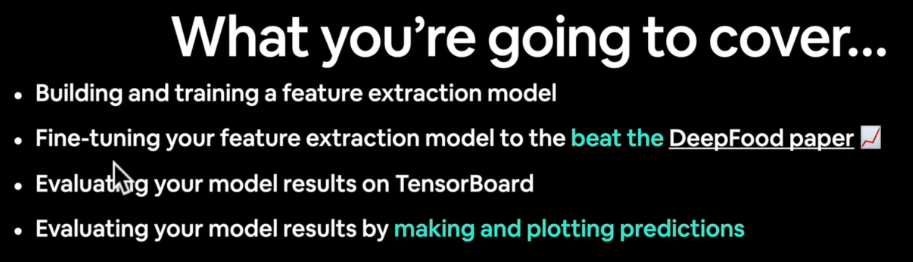

<h1 style="color:red">lec 002:-Making sure we have access to the right GPU for mixed precision training</h1>

# Milestone Project 1: Food Vision Big

See the annotated version of this notebook on Github: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/07_food_vision_milestone_project_1.ipynb

## Check GPU

* Google Colab offers free GPUs (thank you Google), however, not all of them are compatible with mixed precision training.

Google Colab offers:
* K80 (not compatible)
* P100 (not compatible)
* Tesla T4 (compatible)

Knowing this, in order to use mixed precision Training we need access to a Tesla T4 (from within Google Colab) or if we're using our own hardware our GPU need a score of 7.0+ (see here: https://developer.nvidia.com/cuda-gpus)

In [26]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-8718782a-4a9b-d1f7-ff42-1e7ca5aa5c50)


<h1 style="color:red">lec 003:- Getting helper functions ready</h1>

## Get helper functions

In past modules, we've created a bunch of helper functions to do small tasks required for our notebooks.

Rather than rewrite all of these, we can import a script and load them in from there.

The script we've available can be found on github: https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

In [ ]:
# Download helper functions script
!wget "https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py"

--2026-03-13 12:25:30--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py.1’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2026-03-13 12:25:30 (20.1 MB/s) - ‘helper_functions.py.1’ saved [10246/10246]



In [ ]:
# Import series of helper functions for the notebook
from helper_functions import create_tensorboard_callback, plot_loss_curves, compare_historys

<h1 style="color:red">lec 004:-Introduction to TensorFlow Datasets (TFDS)</h1>

## Use TenserFlow Datasets to Download data

If you want to get an overview of TensorFlow Datasets (TFDS), read the guide: https://www.tensorflow.org/datasets/overview

In [ ]:
# Get TensorFlow Datasets
import tensorflow_datasets as tfds

In [ ]:
# List all available datasets
datasets_list = tfds.list_builders() # get all the available datasets in TFDS
print("food101" in datasets_list) # is our target dataset in the list of TFDS datasets?

True


In [ ]:
# Load in the data (takes 5-6 minutes in Google Colab)
(train_data, test_data), ds_info = tfds.load(name="food101",
                                             split=["train","validation"],
                                             shuffle_files = True,
                                             as_supervised=True, # data gets returned in tuple format (data, label)
                                             with_info = True) # for meta-data

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.W70R9C_2.0.0/food101-train.tfrecord*...:   0%|         …

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/food101/incomplete.W70R9C_2.0.0/food101-validation.tfrecord*...:   0%|    …

Dataset food101 downloaded and prepared to /root/tensorflow_datasets/food101/2.0.0. Subsequent calls will reuse this data.


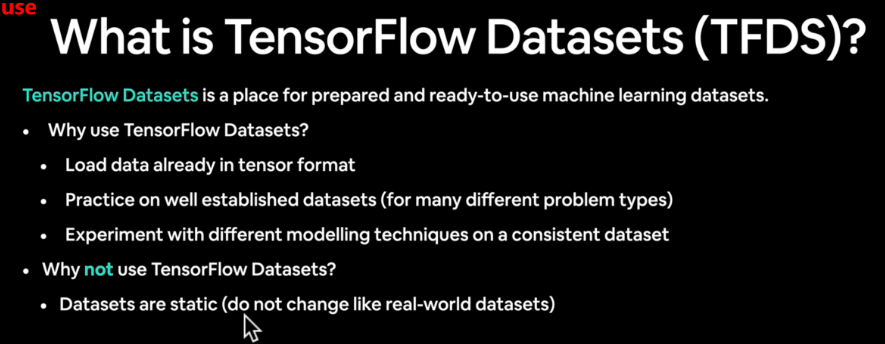

<h1 style="color:red">lec 005:-Exploring and becoming one with the data (Food101 from TensorFlow Datasets)</h1>

## Exploring the Food101 data from TensorFlow Datasets

To become one with our data, we want to find:
* Class names
* The shape of our input data (image tensors)
* The datatype of our input data
* What the labels look like (e.g. are they one-hot encoded or are they label encoded)
* Do the labels match up with the class anmes?

In [27]:
# Features of Food101 from TFDS
ds_info.features


FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [32]:
# Get the class names
class_names = ds_info.features["label"].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [38]:
# Take one sample of the train data
train_one_sample = train_data.take(1) # Samples are in format (image_tensor,label)

In [39]:
# What does ine sample of our training data look like?
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [37]:
label.numpy()

array([40, 72, 47, 14, 63, 57, 88, 11, 68, 66, 11,  1, 89, 56, 83, 37, 18,
       88, 27,  0, 64, 19, 24, 69,  0, 22, 96, 89, 68, 66,  4, 77])

In [36]:
# Output info about our training sample
for image, label in train_one_sample:
  print(f"""
  Image shape: {image.shape}
  Image datatype: {image.dtype}
  Target class from Food101 (tensor form): {label}
  Class name (str form): {class_names[int(label.numpy())]}
  """)

TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
# What does our image tensor from TFDS's Food101 look like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[239, 217, 157],
        [244, 222, 162],
        [247, 227, 168],
        ...,
        [119, 104,  73],
        [111,  95,  70],
        [105,  89,  66]],

       [[233, 212, 149],
        [239, 218, 155],
        [243, 223, 162],
        ...,
        [117, 102,  71],
        [108,  92,  67],
        [101,  85,  62]],

       [[227, 206, 139],
        [234, 213, 146],
        [238, 219, 153],
        ...,
        [117, 100,  70],
        [108,  91,  65],
        [101,  83,  59]],

       ...,

       [[ 35,   7,  19],
        [ 35,   7,  19],
        [ 36,   8,  20],
        ...,
        [198, 181, 127],
        [196, 179, 125],
        [193, 176, 122]],

       [[ 34,   6,  18],
        [ 34,   6,  18],
        [ 35,   7,  19],
        ...,
        [200, 183, 129],
        [201, 184, 130],
        [198, 181, 127]],

       [[ 33,   5,  17],
        [ 34,   6,  18],
        [ 35,   7,  19],
        ...,
        [203, 186, 13

In [ ]:
# What are the min and max value of our image tensor?
import tensorflow as tf
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

### Plot an image from TensorFlow Datasets

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

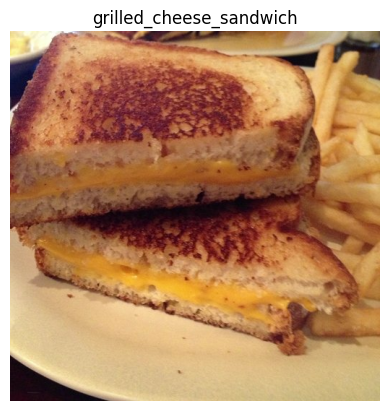

In [ ]:
# Plot an image tensor
import matplotlib.pyplot as plt
plt.imshow(image)
plt.title(class_names[label.numpy()]) # Add title to image to verify the label is associated with the right image
plt.axis(False)

<h1 style="color:red">lec 006:-Creating a preprocessing function to prepare our data for modelling</h1>

## Create preprocessing functions for our data

Neural networks perform best when data is in a certain way (e.g. batched, normalized, etc).

However, not all data (including data from TensorFlow Datasets) comes like this.

So in order to get it ready for a neural network, you'll often have to write preprocessing functions and mao it to your data.

What we know about our data:
* In `uint8` datatype
* Comprised of all different size tensors (different sized images)
* Not scaled (the pixels value are between 0 & 255)

What we know models like:
* Data in `float32` dtype (or for mixed precision `float16/bfloat16` and `float32`) **float16 for GPUs bfloat16 for CPUs and TPUs**
* For batches, TensorFlow likes all of the tensors within a batch to be of the same size
* Scaled (values between 0 & 1) also called normalized tensors generally perform better

With these points in mind, we've got a few things we can tackle with a preprocessing function.

Since we're going to be using an EfficientNetBX pretrained model from tf.keras.applications we don't need to rescale our data (these architectures have rescaling built-in).

This means our function needs to:
1. Reshape our images to all the same size
2. Convert the dtype of our images from `uint8` to `float32`

In [ ]:
# (image,label)

In [ ]:
# Make a function for preprocessing images
def preprocess_img(image, label, img_shape=224):
  """
  Converts image datatype from 'uint8' -> 'float32' and
  reshapes image to (img_shape,img_shape,color_channels)
  """
  image = tf.image.resize(image,[img_shape, img_shape]) # reshape target image
  # image = image/255. # scaled image value (not required with EfficientNetBX models from tf.keras.applications)
  return tf.cast(image,tf.float32), label # return (float32_image, label) tuple

In [ ]:
# Preprocess a single sample image and check the outputs
preprocessed_image = preprocess_img(image,label)[0]
print(f"Image before preprocessing:\n {image[:2]}...\nShape: {image.shape},\nDatatype: {image.dtype}")
print(f"Image after preprocessing:\n {preprocessed_image[:2]}...\nShape: {preprocessed_image.shape},\nDatatype: {preprocessed_image.dtype}")

Image before preprocessing:
 [[[239 217 157]
  [244 222 162]
  [247 227 168]
  ...
  [119 104  73]
  [111  95  70]
  [105  89  66]]

 [[233 212 149]
  [239 218 155]
  [243 223 162]
  ...
  [117 102  71]
  [108  92  67]
  [101  85  62]]]...
Shape: (512, 512, 3),
Datatype: <dtype: 'uint8'>
Image after preprocessing:
 [[[238.7704   217.41327  155.4847  ]
  [242.83673  222.83673  162.55101 ]
  [240.85713  220.20918  164.2143  ]
  ...
  [131.28564  118.28565   75.7806  ]
  [123.88257  109.81113   75.09689 ]
  [106.698746  90.698746  66.4131  ]]

 [[232.16325  212.09183  141.37755 ]
  [238.86224  219.86224  151.07654 ]
  [239.94388  221.08673  155.87245 ]
  ...
  [127.49998  112.49998   71.07145 ]
  [122.63767  106.56623   72.852   ]
  [105.83142   88.47424   63.1886  ]]]...
Shape: (224, 224, 3),
Datatype: <dtype: 'float32'>


<h1 style="color:red">lec 007:-Batching and preparing our datasets (to make them run fast)</h1>

## Batch and prepare datasets

We're now going to make our data input pipelines run really fast.

For more resources on this , I'd highly recommend going through the following guide: https://www.tensorflow.org/guide/data_performance

In [ ]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [ ]:
# Map preprocessing functions to training (and parallelize)
train_data = train_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
# Shuffle train_data and turn it into batches and prefetch it (load it faster)
train_data = train_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)
# buffer_size ideally len(train_data) but we don't have enough ram to shuffle all at once so 1000

# Map preprocessing function to test data
test_data = test_data.map(map_func=preprocess_img,num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)#.cache()
# .cache() it loads the values in RAM and while training it fetch faster but it only works when RAM can store all the data

In [40]:
train_data, test_data

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

<h1 style="color:red">lec 008:-Exploring what happens when we batch and prefetch our data</h1>

> "Hey, TensorFlow, map this preprocessing function (`preprocess_img`) across our training dataset, then shuffle a number of elements and then batch them together and finally make sure you preprare new batches (prefetch) whilst the model is looking through (finding patterns) the current batch."

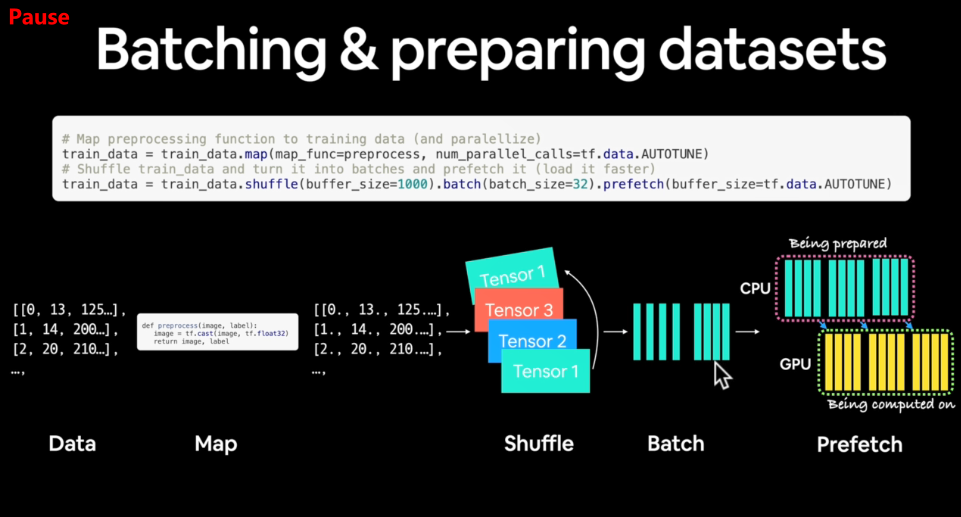

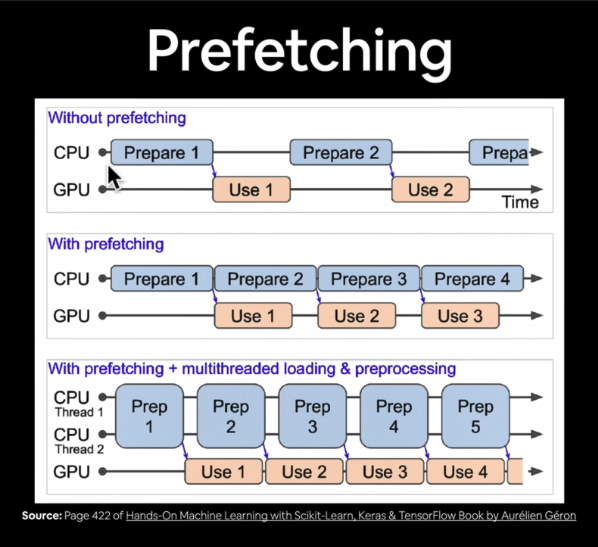

<h1 style="color:red">lec 009:-Creating modelling callbacks for our feature extraction model</h1>

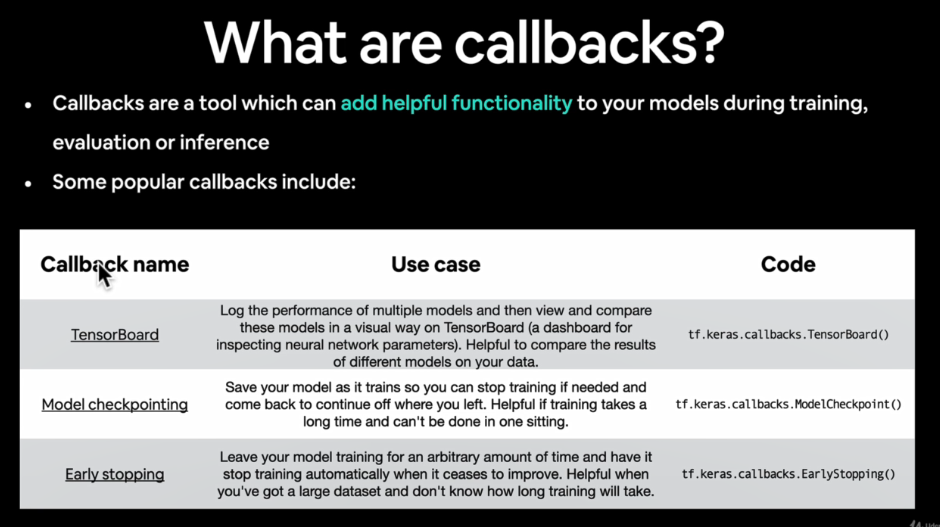

## Create modelling calllbacks

We're going to create a couple of callbacks to help us while our model trains:
* Tensorboard callbacks to log training results (so we can visualize them later if need be).
* ModelCheckpoint callback to save our model's progress after feature extraction.


In [42]:
# Create tensorboard callback (import from helper_functions.py)
from helper_functions import create_tensorboard_callback

# Create ModelCheckpoint callback to save a model's progress during training
checkpoint_path = "model_checkpoints/cp.weights.h5"
model_checkpoint = tf.keras.callbacks.ModelCheckpoint(checkpoint_path,
                                                      monitor="val_acc",
                                                      save_best_only=True,
                                                      save_weights_only=True,
                                                      verbose=0) # don't print whether or not model is being saved

<h1 style="color:red">lec 010:-Turning on mixed precision training with TensorFlow</h1>

## Setup mixed precision training

First and foremost, for a deeper understanding of mixed precision training, check out the TensorFlow guide for mixed precision: https://www.tensorflow.org/guide/mixed_precision

Mixed precision utilizes a combination of float32 and float16 data types to speed up model performance.

In [43]:
# Turn on mixed precision training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy("mixed_float16") # set global data policy to mixed precision

In [44]:
print(mixed_precision.global_policy())

<DTypePolicy "mixed_float16">


In [45]:
tf.config.experimental.get_device_details(
    tf.config.list_physical_devices('GPU')[0]
)

{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}

<h1 style="color:red">lec 011:-Creating a feature extraction model capable of using mixed precision training</h1>

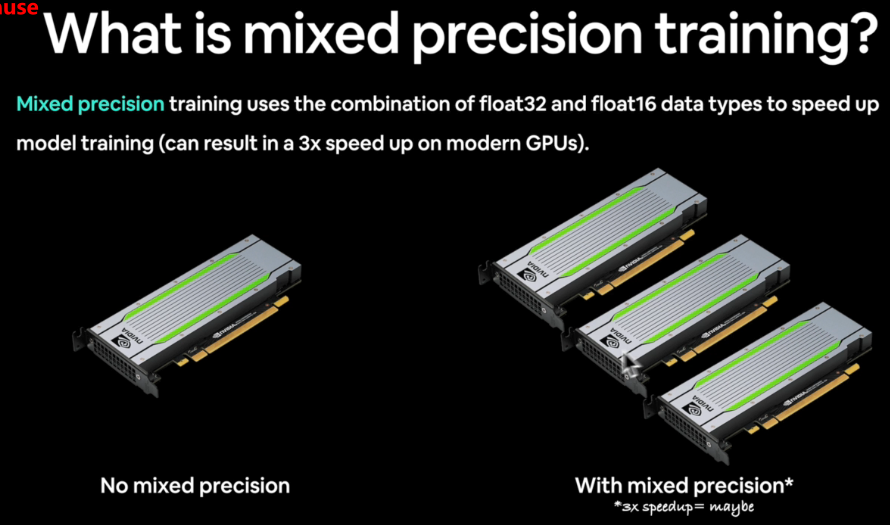

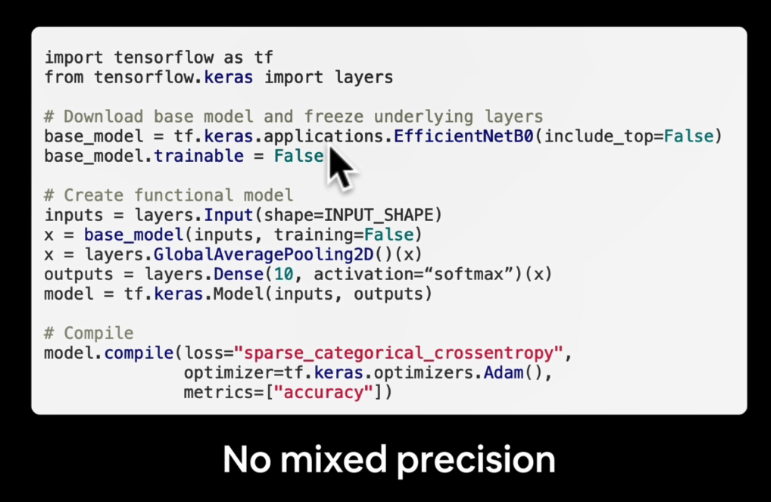

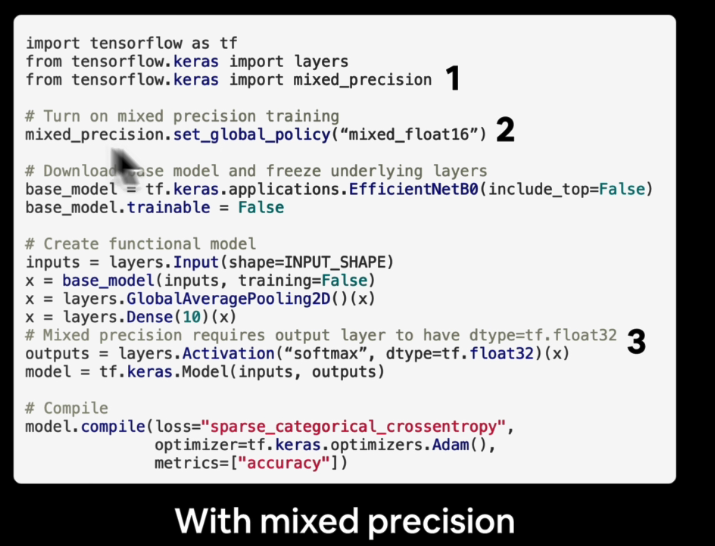

## Build feature extraction model

In [47]:
from tensorflow.keras import layers

# Create base model
input_shape = (224,224,3)
base_model = tf.keras.applications.EfficientNetB0(include_top=False)
base_model.trainable = False;

# Create functional model
inputs = layers.Input(shape=input_shape,name = "input_layer")
## Note: EfficientNetBX models have rescaling built-in but if your model doesn't you can have a layer like below
# x = layers.Rescaling(1/255.)(inputs)

x =base_model(inputs,training=False) # make sure layers which should be in inference mode only stay like that
x =layers.GlobalAveragePooling2D()(x)
x = layers.Dense(len(class_names))(x)
outputs = layers.Activation("softmax",dtype=tf.float32,name="softmax_float32")(x)
model = tf.keras.Model(inputs,outputs)

# Compile the model
# our model's labels are in integer form not one-hot-encoded so we are going to use sparse_categorical_crossentropy loss
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=tf.keras.optimizers.Adam(),
              metrics=["accuracy"])

In [48]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 101)            │       129,381 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_float32 (Activation)    │ (None, 101)            │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,178,952 (15.94 MB)

 Trainable params: 129,381 (505.39 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

<h1 style="color:red">lec 012:-Checking to see if our model is using mixed precision training layer by layer</h1>

## Checking layer dtype policies (are we using mixed precision?)

In [49]:
# check the dtype_policy attributes of layers in our model
for layer in model.layers:
  print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer True float32 <DTypePolicy "mixed_float16">
efficientnetb0 False float32 <DTypePolicy "mixed_float16">
global_average_pooling2d_1 True float32 <DTypePolicy "mixed_float16">
dense_1 True float32 <DTypePolicy "mixed_float16">
softmax_float32 True float32 <DTypePolicy "float32">


Going through the above we see:
* `layer.name`: the human readable name of a particular layer
* `layer.trainable`: is the layer trainable or not? (if `False`, the weights are frozen)
* `layer.dtype`: the datatype a layer stores its variables in
* `layer.dtype_policy`: the data type policy a layer computes on its variables with

In [52]:
# Check the dtype_policy attributes of layers in the base model
for layer in model.layers[1].layers[:20]:
  print(layer.name, layer.trainable, layer.dtype, layer.dtype_policy)

input_layer_1 False float32 <DTypePolicy "mixed_float16">
rescaling_2 False float32 <DTypePolicy "mixed_float16">
normalization_1 False float32 <DTypePolicy "mixed_float16">
rescaling_3 False float32 <DTypePolicy "mixed_float16">
stem_conv_pad False float32 <DTypePolicy "mixed_float16">
stem_conv False float32 <DTypePolicy "mixed_float16">
stem_bn False float32 <DTypePolicy "mixed_float16">
stem_activation False float32 <DTypePolicy "mixed_float16">
block1a_dwconv False float32 <DTypePolicy "mixed_float16">
block1a_bn False float32 <DTypePolicy "mixed_float16">
block1a_activation False float32 <DTypePolicy "mixed_float16">
block1a_se_squeeze False float32 <DTypePolicy "mixed_float16">
block1a_se_reshape False float32 <DTypePolicy "mixed_float16">
block1a_se_reduce False float32 <DTypePolicy "mixed_float16">
block1a_se_expand False float32 <DTypePolicy "mixed_float16">
block1a_se_excite False float32 <DTypePolicy "mixed_float16">
block1a_project_conv False float32 <DTypePolicy "mixed_fl

In [53]:
# mixed_precision.set_global_policy('mixed_float32') we shouldn't do this now we want our model to trains faster

<h1 style="color:red">lec 013:-Training and evaluating a feature extraction model (Food Vision Big)</h1>

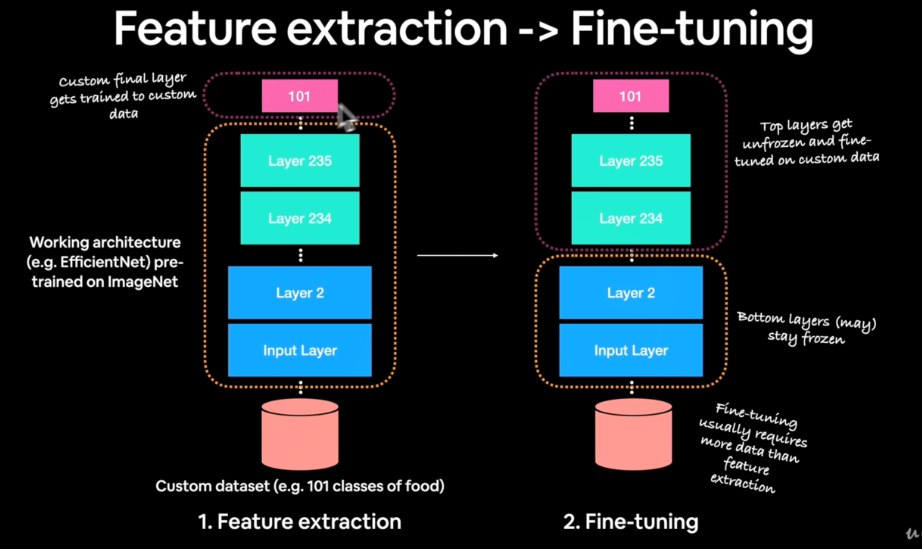

## Fit the feature extraction model

If our goal is to fine-tune a pretrained model, the general order of doing things is:
1. Build a feature extraction model (train a couple output layers with base layers frozen)
2. Fine-tune some of the frozen layers

In [ ]:
# Fit the feature extraction model with callbacks
history_101_food_classes_feature_extract = model.fit(train_data,
                                                     epochs=3,
                                                     steps_per_epoch= len(train_data),
                                                     validation_data = test_data,
                                                     validation_steps = int(0.5*len(test_data),
                                                     callbacks = [create_tensorboard_callback(dir_name="training_logs",
                                                                                              experiment_name = "efficientnetbo_101_classes_all_data_feature_extract"),
                                                                  model_checkpoint]))

In [ ]:
# Evaluate model on whole test dataset
results_feature_extract = model.evaluate(test_data)
results_feature_extract

<h1 style="color:red">lec 014:-Introducing your Milestone Project 1 challenge_ build a model to beat DeepFood</h1>

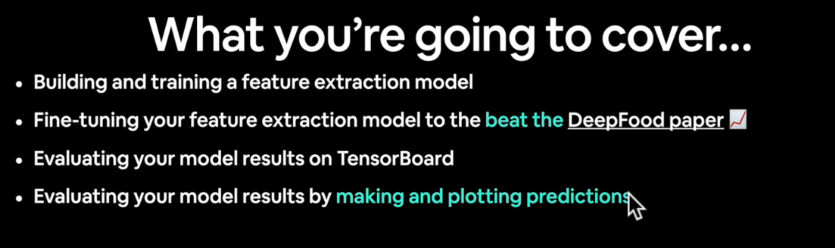

## Off to you...

We've covered a lot of ground so far but since this is a milestone project, it's time for you to takeover.

More specifically, your challenge is to complete the TEMPELATE version of 07 to obtain a computer vision model (building off the one we've built in this notebook) to beat the DeepFood paper.

In other words, you're going to create Food vision Big!!!

You can find the Tempelate notebook here: https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/TEMPLATE_07_food_vision_milestone_project_1.ipynb

And if you get stuck, you can refer to the example version (non-template): https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/07_food_vision_milestone_project_1.ipynb

<body>
                <div class="container">
                <div class="row">
                <div class="col-md-10 col-md-offset-1">
                    <p class="lead"><p>How'd you go?</p><p>Did you make it through?</p><p>Did you manage to train a model to beat the DeepFood paper?</p><p>If you did, congratulations!</p><p>Experimenting and figuring things out for yourself is a valuable skill in the world of machine learning (and software development in general).</p><p>You should now be able to:</p><ul><li><p>Use TensorFlow Datasets (TFDS) to download a ready-made (already in tensors) dataset</p></li><li><p>Preprocess your data to be used with a model (make sure all the data types are correct)</p></li><li><p>Create efficient data pipelines using <code>tf.data</code> API methods like <code>batch()</code> and <code>prefetch()</code></p></li></ul><p>If you went through the Milestone Project 1 Template, you've already done plenty of practice but if you're up for it (I think you are), there's more.</p><p>In the <a href="https://github.com/mrdbourke/tensorflow-deep-learning" rel="noopener noreferrer" target="_blank">course GitHub repo</a> under “Course materials”, you'll find a series of exercises and extra-curriculum suggestions.</p><p>You should go through these <strong>before</strong> moving on to the next section.</p><p>See the link below for more.</p><ul><li><p><a href="https://github.com/mrdbourke/tensorflow-deep-learning#-07-milestone-project-1--food-vision-big-exercises" rel="noopener noreferrer" target="_blank">Milestone Project 1: Food Vision Big™ Exercises and Extra-Curriculum</a></p></li></ul><p>And remember, if you have any questions, be sure to <a href="https://github.com/mrdbourke/tensorflow-deep-learning/discussions" rel="noopener noreferrer" target="_blank">add them to the discussions page</a>.</p><p><strong>Challenge:</strong> Which predictions did your model get most wrong? Why do you think this is?</p><p>I'd love to see 3 of your model's most wrong predictions and why you think it got them wrong</p><p>Send a message with 3 of your model's most wrong predictions to the #machinelearning-datascience channel on Discord and mention my name (@mrdbourke).</p><p>See you in the next module! Time for Natural Language Processing (NLP)!</p><p>- Daniel</p><p>Web: <a href="http://www.mrdbourke.com/" rel="noopener noreferrer" target="_blank">www.mrdbourke.com</a></p><p>YouTube: <a href="https://dbourke.link/youtube" rel="noopener noreferrer" target="_blank">https://dbourke.link/youtube</a></p></p>
                </div>
                </div>
                </div>
                <script src="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.7/js/bootstrap.min.js" integrity="sha384-Tc5IQib027qvyjSMfHjOMaLkfuWVxZxUPnCJA7l2mCWNIpG9mGCD8wGNIcPD7Txa" crossorigin="anonymous"></script>
                </body>